In [2]:
import pandas as pd  
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns 

In [3]:
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,n_features=2,centers=3)

In [4]:
x

array([[-5.78457249,  4.84707059],
       [-4.3031846 ,  4.97508252],
       [-4.42790754,  6.67906282],
       ...,
       [ 4.22137772,  7.7562451 ],
       [ 3.5545194 , -8.09753689],
       [ 5.29819677, -6.16758278]])

In [5]:
y

array([1, 1, 1, 0, 1, 2, 0, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2,
       1, 1, 0, 1, 0, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 0, 1, 1, 2, 1, 1, 0,
       1, 1, 1, 1, 2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 2, 1, 1, 0, 1, 1, 2, 2,
       2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 1, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 2, 0, 2, 1, 0, 0, 0, 2, 2, 2, 0, 2, 1, 2, 1, 2, 1, 1,
       2, 0, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 0, 1, 1, 2, 2, 1, 1, 0, 2, 2,
       2, 2, 1, 2, 1, 1, 0, 1, 2, 2, 1, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0, 0,
       2, 0, 1, 0, 2, 1, 2, 2, 1, 2, 0, 0, 1, 0, 2, 0, 2, 1, 2, 2, 2, 0,
       2, 1, 0, 1, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 0, 2, 0, 2, 2, 0, 0, 2,
       1, 1, 0, 2, 1, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 1, 0, 2, 0, 1, 2, 1,
       1, 2, 1, 1, 1, 2, 1, 0, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 0, 2, 2, 2,
       2, 2, 0, 1, 2, 2, 0, 2, 1, 0, 1, 0, 1, 2, 2, 0, 0, 0, 0, 2, 1, 2,
       0, 2, 0, 1, 0, 2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 2, 1,
       0, 2, 0, 0, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 1,

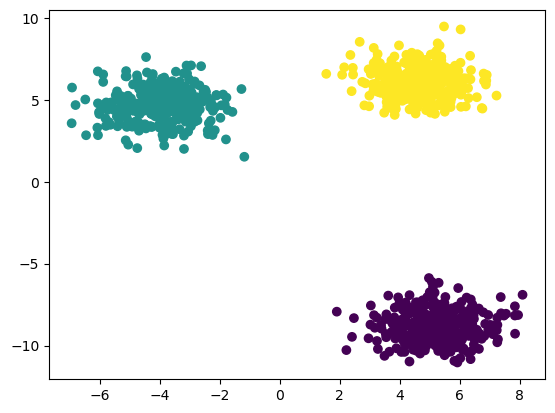

In [6]:
plt.scatter(x[:,0],x[:,1],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
#elbow method to select the k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans=kmeans.fit(x_train_scaled)
    wcss.append( kmeans.inertia_)



c:\Users\Asus\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Asus\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

In [11]:
 kmeans

KMeans(n_clusters=10)

In [12]:
wcss

[1340.0000000000002,
 495.01811732959055,
 47.9949657627313,
 40.741424113100386,
 33.25609483950672,
 31.279311075674098,
 23.88254397640681,
 21.832114152436933,
 20.079851289526378,
 18.358758270538083]

Text(0, 0.5, 'wcss')

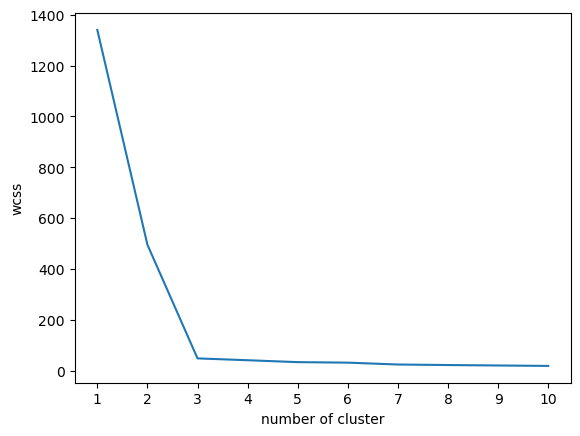

In [13]:
#plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of cluster")
plt.ylabel("wcss")

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(x_train_scaled)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 2, 2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 0, 0, 1, 1,
       0, 2, 0, 2, 1, 2, 0, 1, 1, 1, 2, 0, 0, 1, 0, 2, 1, 2, 0, 1, 2, 2,
       0, 0, 1, 0, 2, 1, 0, 0, 1, 1, 1, 1, 1, 2, 0, 2, 2, 1, 2, 1, 2, 0,
       0, 1, 0, 2, 0, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 2, 1, 0, 1, 0, 0, 1,
       2, 2, 1, 2, 2, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0, 1,
       1, 0, 2, 0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 2, 0, 1, 0, 1, 2, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 0, 0, 2, 2, 2,
       0, 0, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 0, 1, 2, 2, 0, 2,
       1, 2, 0, 2, 0, 0, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 2, 2, 2, 2,
       1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 0, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 0, 1, 1, 0, 1, 2, 0, 0, 2, 1, 2, 1, 1, 1, 1, 0, 2, 1,
       1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 0, 2, 2, 2, 0, 1, 1, 0, 1, 1, 0, 2,
       0, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 1, 0, 2, 1, 0, 0, 0, 0, 1, 2, 1,
       0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2,

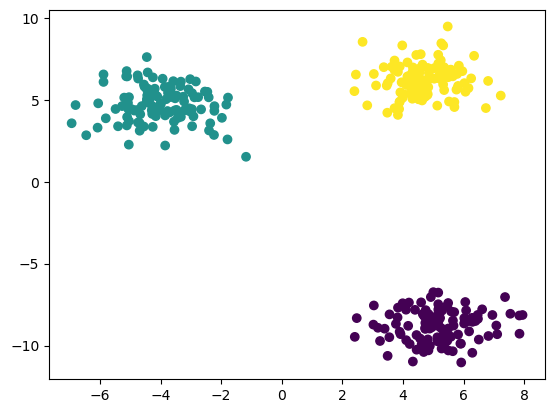

In [17]:
y_pred=kmeans.predict(x_test_scaled)
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [18]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [19]:
from kneed import KneeLocator
k1=KneeLocator(range(1,11),wcss,curve="convex",direction='decreasing')

In [20]:
k1.elbow


np.int64(3)

In [25]:
from sklearn.metrics import silhouette_score

silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [26]:
silhouette_coefficients

[np.float64(0.6467069365597238),
 np.float64(0.8373726781596822),
 np.float64(0.6914297599875069),
 np.float64(0.5222224701383782),
 np.float64(0.5241610388650054),
 np.float64(0.3695636830207634),
 np.float64(0.347193805049614),
 np.float64(0.31825482131049426),
 np.float64(0.3689294797749992)]

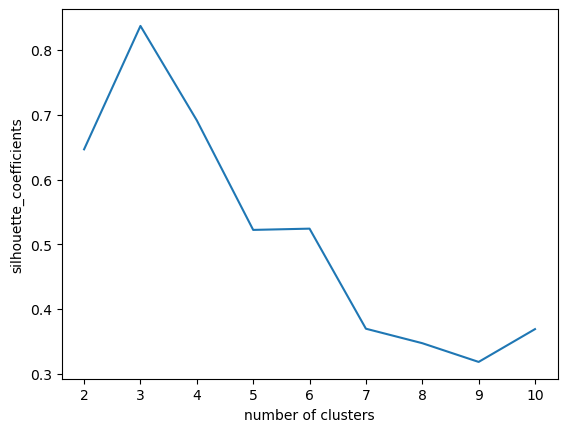

In [ ]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette_coefficients")
plt.show()
# here the point will be k value